# Cell 1:

# RapidRelief — Model Training
This notebook will train and save the Logistic Regression and Random Forest models.

Models trained here:
- **Logistic Regression** : baseline model using TF-IDF features
- **Random Forest** : ensemble model using TF-IDF features

Will atempt to RoBERTa train separately on Google Colab (to deal with GPU requirements).

Output files:
- `backend/models/lr_model.pkl` — saved Logistic Regression model
- `backend/models/rf_model.pkl` — saved Random Forest model
- `backend/models/tfidf_vectorizer.pkl` — saved TF-IDF vectorizer

In [22]:
# Cell 2:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn — for TF-IDF, models, and evaluation metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# Add backend to path so we can import preprocess.py
sys.path.append(os.path.abspath("../../backend"))
from utils.preprocess import preprocess_text

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("All imports successful")

All imports successful


In [21]:
# Cell 3:
# ---------------------------------------------------------------------------
# Load datasets and map labels to urgency levels
# We combine all datasets into one unified training set
# Each dataset has different label formats so we map them to the rankings of:
# Critical, High, Medium, Low
# ---------------------------------------------------------------------------

DATA_PATH = "../../backend/data/"

# ---------------------------------------------------------------------------
# Loads our own fake test messages
# which already has an urgency_level column
# ---------------------------------------------------------------------------
df_test = pd.read_csv(DATA_PATH + "training_data.csv")
df_test = df_test[["text", "urgency_level"]].copy()
df_test.columns = ["text", "urgency_label"]

# ---------------------------------------------------------------------------
# Load in the Kaggle disaster tweets
# Setting target: 1 = real disaster, 0 = not disaster
# Map: 1 → High, 0 → Low
# ---------------------------------------------------------------------------
df_kaggle = pd.read_csv(DATA_PATH + "kaggle_disaster.csv")
df_kaggle = df_kaggle[["text", "target"]].dropna()
df_kaggle["urgency_label"] = df_kaggle["target"].map({1: "High", 0: "Low"})
df_kaggle = df_kaggle[["text", "urgency_label"]]

# ---------------------------------------------------------------------------
# Load CrisisLex combined
# Labels: Related and informative, Related but is not informative, Not related, or Not applicable
# Map to urgency levels based on informativeness
# ---------------------------------------------------------------------------
df_crisislex = pd.read_csv(DATA_PATH + "crisislex_combined.csv")
crisislex_map = {
    "Related and informative":          "High",
    "Related but is not informative":    "Medium",
    "Not related":                      "Low",
    "Not applicable":                   "Low",
}
df_crisislex["urgency_label"] = df_crisislex["label"].map(crisislex_map)
df_crisislex = df_crisislex[["text", "urgency_label"]].dropna()

# ---------------------------------------------------------------------------
# Load CrisisNLP humanitarian categories
# Mapping humanitarian categories to urgency levels
# ---------------------------------------------------------------------------
df_crisisnlp = pd.read_csv(DATA_PATH + "crisisnlp_train.tsv", sep="\t")
crisisnlp_map = {
    "injured_or_dead_people":           "Critical",
    "missing_and_found_people":         "Critical",
    "displaced_and_evacuations":        "High",
    "infrastructure_and_utilities_damage": "High",
    "caution_and_advice":               "High",
    "affected_individual":              "High",
    "requests_or_needs":                "Medium",
    "sympathy_and_support":             "Medium",
    "donation_and_volunteering":        "Medium",
    "response_efforts":                 "Medium",
    "not_humanitarian":                 "Low",
}
df_crisisnlp["urgency_label"] = df_crisisnlp["class_label"].map(crisisnlp_map)
df_crisisnlp = df_crisisnlp[["text", "urgency_label"]].dropna()

# ---------------------------------------------------------------------------
# Combine all datasets into one
# ---------------------------------------------------------------------------
df_combined = pd.concat([
    df_test,
    df_kaggle,
    df_crisislex,
    df_crisisnlp
], ignore_index=True)

# Drop any remaining nulls
df_combined = df_combined.dropna(subset=["text", "urgency_label"])

print(f"Combined dataset: {len(df_combined):,} total messages")
print(f"\nUrgency label distribution:")
print(df_combined["urgency_label"].value_counts())
print(f"\nClass percentages:")
print((df_combined["urgency_label"].value_counts(normalize=True) * 100).round(1))

Combined dataset: 92,753 total messages

Urgency label distribution:
urgency_label
Low         48683
High        27416
Medium      14334
Critical     2320
Name: count, dtype: int64

Class percentages:
urgency_label
Low         52.5
High        29.6
Medium      15.5
Critical     2.5
Name: proportion, dtype: float64


In [3]:
# Cell 4:
# ---------------------------------------------------------------------------
# Apply preprocess_text() to all messages
# This is the same function used for live user input in the app
# Ensures training data and live data are cleaned identically
# ---------------------------------------------------------------------------

print("Preprocessing text... this may take a minute.")
df_combined["cleaned_text"] = df_combined["text"].apply(preprocess_text)

# Remove any empty strings that resulted from preprocessing
df_combined = df_combined[df_combined["cleaned_text"].str.strip() != ""]

print(f"Preprocessing complete.")
print(f"Total cleaned messages: {len(df_combined):,}")
print(f"\nSample cleaned messages:")
for i in range(3):
    print(f"\n  Raw:     {df_combined['text'].iloc[i][:80]}")
    print(f"  Cleaned: {df_combined['cleaned_text'].iloc[i][:80]}")

Preprocessing text... this may take a minute.
Preprocessing complete.
Total cleaned messages: 100,424

Sample cleaned messages:

  Raw:     Building collapsed, people trapped inside need help immediately
  Cleaned: building collapsed people trapped inside need help immediately

  Raw:     Multiple casualties reported at the intersection of Main and 5th
  Cleaned: multiple casualties reported at the intersection of main and 5th

  Raw:     Wildfire spreading rapidly towards residential area
  Cleaned: wildfire spreading rapidly towards residential area


In [4]:
# Cell 5:
# ---------------------------------------------------------------------------
# Split data into 80% training and 20% testing
# Stratify ensures each urgency level is proportionally represented
# in both train and test sets
# ---------------------------------------------------------------------------

X = df_combined["cleaned_text"]
y = df_combined["urgency_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% held out for testing
    random_state=42,        # fixed seed for reproducibility
    stratify=y              # maintain class distribution in both splits
)

print(f"Training set:  {len(X_train):,} messages ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:      {len(X_test):,} messages ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining label distribution:")
print(y_train.value_counts())

Training set:  80,339 messages (80.0%)
Test set:      20,085 messages (20.0%)

Training label distribution:
urgency_label
Low         38926
High        21922
Medium      17635
Critical     1856
Name: count, dtype: int64


In [5]:
# Cell 6:
# ---------------------------------------------------------------------------
# TF-IDF Vectorization
# Converts cleaned text into numerical feature vectors
# TF-IDF = Term Frequency - Inverse Document Frequency
# Words that appear often in one message but rarely across all messages
# get higher scores which is good for identifying the language for emergency related
# ---------------------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=10000,     # top 10,000 features of important key words such as heart attack, building collapses, etc
    ngram_range=(1, 2),     # unigrams/bigrams to gather single words and two word phrases
    min_df=2,               # ignore terms appearing in fewer than 2 docs
    max_df=0.95,            # ignore terms appearing in more than 95% of docs
    sublinear_tf=True,      # applies log normalization to term frequencies
)

# Fit on training data only — never fit on test data (data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"\nTop 20 TF-IDF features:")
feature_names = tfidf.get_feature_names_out()
print(list(feature_names[:20]))

TF-IDF matrix shape (train): (80339, 10000)
TF-IDF matrix shape (test):  (20085, 10000)

Top 20 TF-IDF features:
['000', '02', '078952020', '078969502', '10', '10 to', '100', '100 injured', '100 of', '100 people', '1000', '1000 people', '10000', '10000 people', '100000', '101', '1035', '10am', '10km', '10pm']


In [6]:
# Cell 7:
# ---------------------------------------------------------------------------
# Compute class weights
# Because our dataset is imbalanced (more Low than Critical messages)
# we tell the models to pay more attention to rare classes
# This prevents the model from just predicting Low for everything
# ---------------------------------------------------------------------------

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, weights))

print("Class weights (higher = model pays more attention):")
for label, weight in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"  {label:<10} → {weight:.4f}")

Class weights (higher = model pays more attention):
  Critical   → 10.8215
  Medium     → 1.1389
  High       → 0.9162
  Low        → 0.5160


In [20]:
# Cell 8:
# ---------------------------------------------------------------------------
# Train Logistic Regression model (lr)
# This is our baseline model for text classification
# To prevent overfitting, using L2 regularization
# ---------------------------------------------------------------------------

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    C=1.0,                          # regularization strength
    max_iter=1000,                  # max iterations for convergence for larger size datasets
    class_weight=class_weight_dict, # handle class imbalance
    random_state=42,
    n_jobs=-1,                      # use all CPU cores
    verbose=0
)

lr_model.fit(X_train_tfidf, y_train)

# Evaluate on test set
lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions, average="weighted")
lr_precision = precision_score(y_test, lr_predictions, average="weighted")
lr_recall = recall_score(y_test, lr_predictions, average="weighted")

print(f"\nLogistic Regression Results:")
print(f"  Accuracy:  {lr_accuracy:.4f} ({lr_accuracy*100:.1f}%)")
print(f"  F1 Score:  {lr_f1:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, lr_predictions))

Training Logistic Regression...

Logistic Regression Results:
  Accuracy:  0.8054 (80.5%)
  F1 Score:  0.8088
  Precision: 0.8159
  Recall:    0.8054

Detailed Classification Report:
              precision    recall  f1-score   support

    Critical       0.47      0.83      0.60       464
        High       0.79      0.77      0.78      5480
         Low       0.90      0.85      0.87      9732
      Medium       0.70      0.75      0.72      4409

    accuracy                           0.81     20085
   macro avg       0.71      0.80      0.74     20085
weighted avg       0.82      0.81      0.81     20085



In [19]:
# Cell 9:
# ---------------------------------------------------------------------------
# Train Random Forest model (rf)
# Ensemble of decision trees — more powerful than Logistic Regression
# ---------------------------------------------------------------------------

print("Training Random Forest... (this takes a minute)")

rf_model = RandomForestClassifier(
    n_estimators=200,               # number of trees
    max_depth=None,                 # grow trees fully
    min_samples_split=5,            # min samples to split a node
    min_samples_leaf=2,             # min samples at leaf node
    class_weight=class_weight_dict, # handle class imbalance
    random_state=42,
    n_jobs=-1,                      # use all CPU cores
    verbose=0
)

rf_model.fit(X_train_tfidf, y_train)

# Evaluate on test set
rf_predictions = rf_model.predict(X_test_tfidf)
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions, average="weighted")
rf_precision = precision_score(y_test, rf_predictions, average="weighted")
rf_recall = recall_score(y_test, rf_predictions, average="weighted")

print(f"\nRandom Forest Results:")
print(f"  Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.1f}%)")
print(f"  F1 Score:  {rf_f1:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, rf_predictions))

Training Random Forest... (this takes a minute)

Random Forest Results:
  Accuracy:  0.7796 (78.0%)
  F1 Score:  0.7817
  Precision: 0.7865
  Recall:    0.7796

Detailed Classification Report:
              precision    recall  f1-score   support

    Critical       0.42      0.78      0.54       464
        High       0.77      0.74      0.75      5480
         Low       0.86      0.86      0.86      9732
      Medium       0.68      0.67      0.68      4409

    accuracy                           0.78     20085
   macro avg       0.68      0.76      0.71     20085
weighted avg       0.79      0.78      0.78     20085



In [9]:
# Cell 10:
# ---------------------------------------------------------------------------
# Save trained models to backend/models/
# These files will get loaded by classifier.py when the FastAPI server initiates
# .pkl format = Python pickle — standard for saving sklearn models
# ---------------------------------------------------------------------------

MODELS_PATH = "../../backend/models/"
os.makedirs(MODELS_PATH, exist_ok=True)

# Save Logistic Regression
with open(MODELS_PATH + "lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)
print("Saved: backend/models/lr_model.pkl")

# Save Random Forest
with open(MODELS_PATH + "rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Saved: backend/models/rf_model.pkl")

# Save TF-IDF vectorizer
# Saving for classifier.py to transform live user input the same way training data was transformed
with open(MODELS_PATH + "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
print("Saved: backend/models/tfidf_vectorizer.pkl")

print("\nAll models saved successfully!")

Saved: backend/models/lr_model.pkl
Saved: backend/models/rf_model.pkl
Saved: backend/models/tfidf_vectorizer.pkl

All models saved successfully!


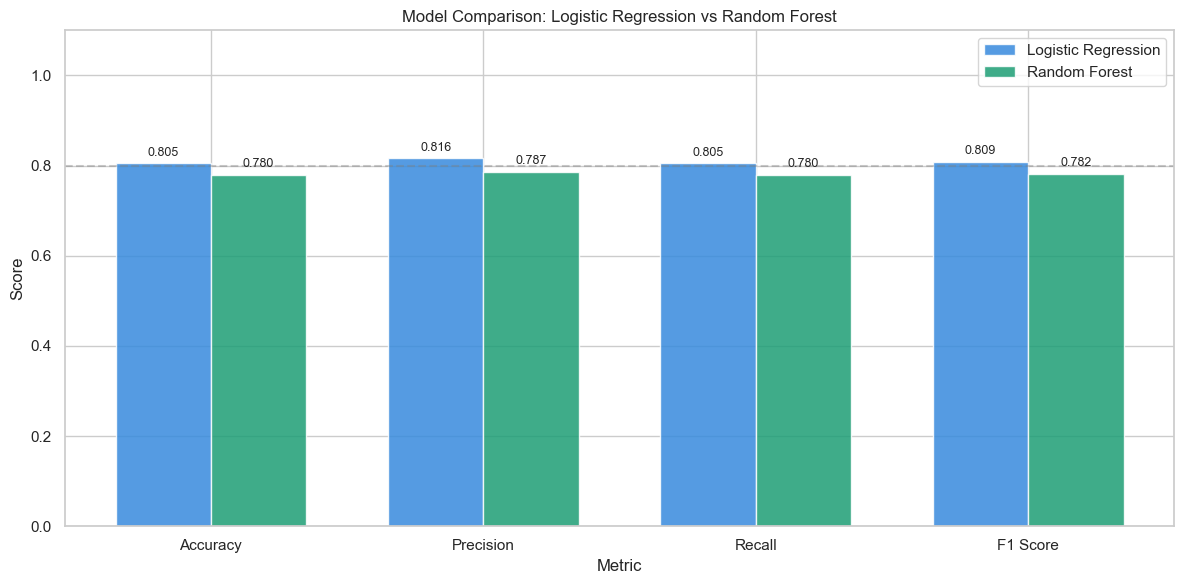

Model comparison chart saved.


In [10]:
# Cell 11:
# ---------------------------------------------------------------------------
# Chart: Side by side model comparison
# Shows accuracy, precision, recall, F1 for both models
# This chart showcases our results section
# ---------------------------------------------------------------------------

metrics = {
    "Accuracy":  [lr_accuracy,  rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall":    [lr_recall,    rf_recall],
    "F1 Score":  [lr_f1,        rf_f1],
}

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()],
               width, label="Logistic Regression", color="#378ADD", alpha=0.85)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()],
               width, label="Random Forest", color="#1D9E75", alpha=0.85)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Logistic Regression vs Random Forest")
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4, label="0.8 threshold")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../../backend/data/chart_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Model comparison chart saved.")

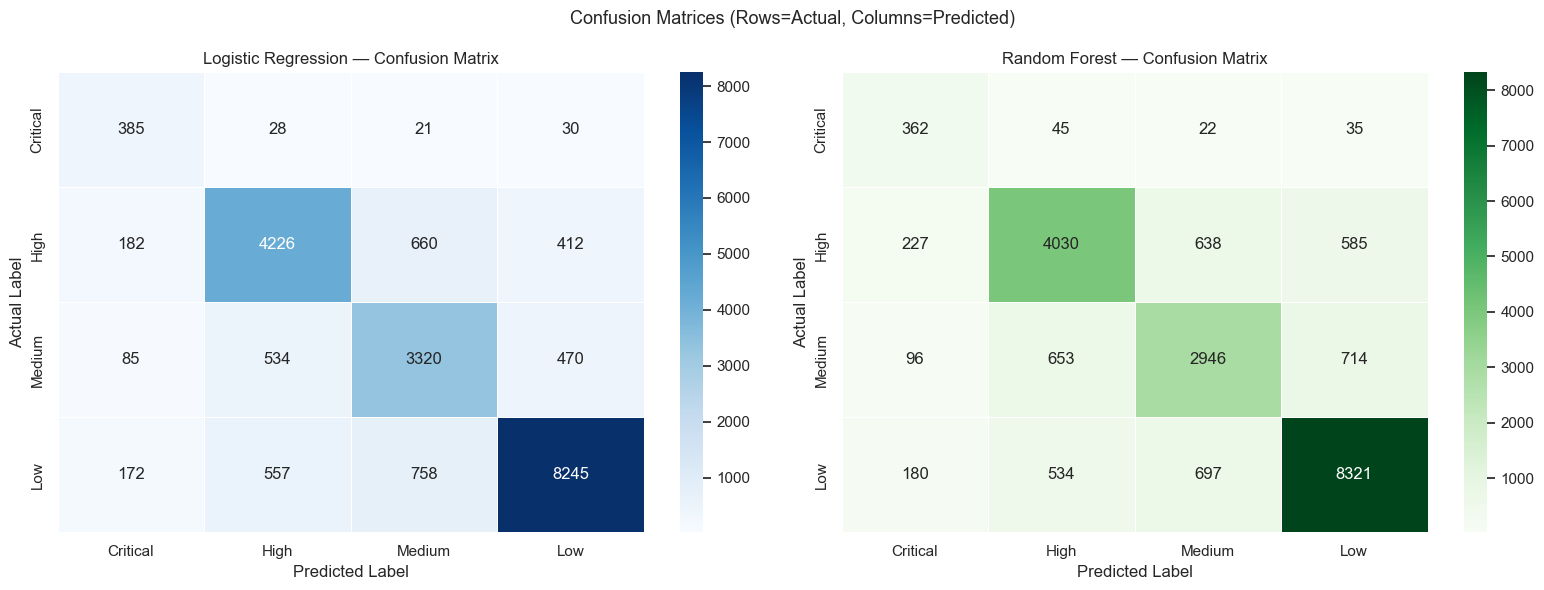

In [11]:
# Cell 12:
# ---------------------------------------------------------------------------
# Confusion matrices for both models (lr and rf)
# Shows which urgency levels get misclassified and how often
# Rows = actual labels, Columns = predicted labels
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_order = ["Critical", "High", "Medium", "Low"]

for ax, (predictions, model_name, color) in zip(axes, [
    (lr_predictions, "Logistic Regression", "Blues"),
    (rf_predictions, "Random Forest",       "Greens"),
]):
    cm = confusion_matrix(y_test, predictions, labels=label_order)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=color,
        xticklabels=label_order,
        yticklabels=label_order,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f"{model_name} — Confusion Matrix")
    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices (Rows=Actual, Columns=Predicted)", fontsize=13)
plt.tight_layout()
plt.savefig("../../backend/data/chart_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

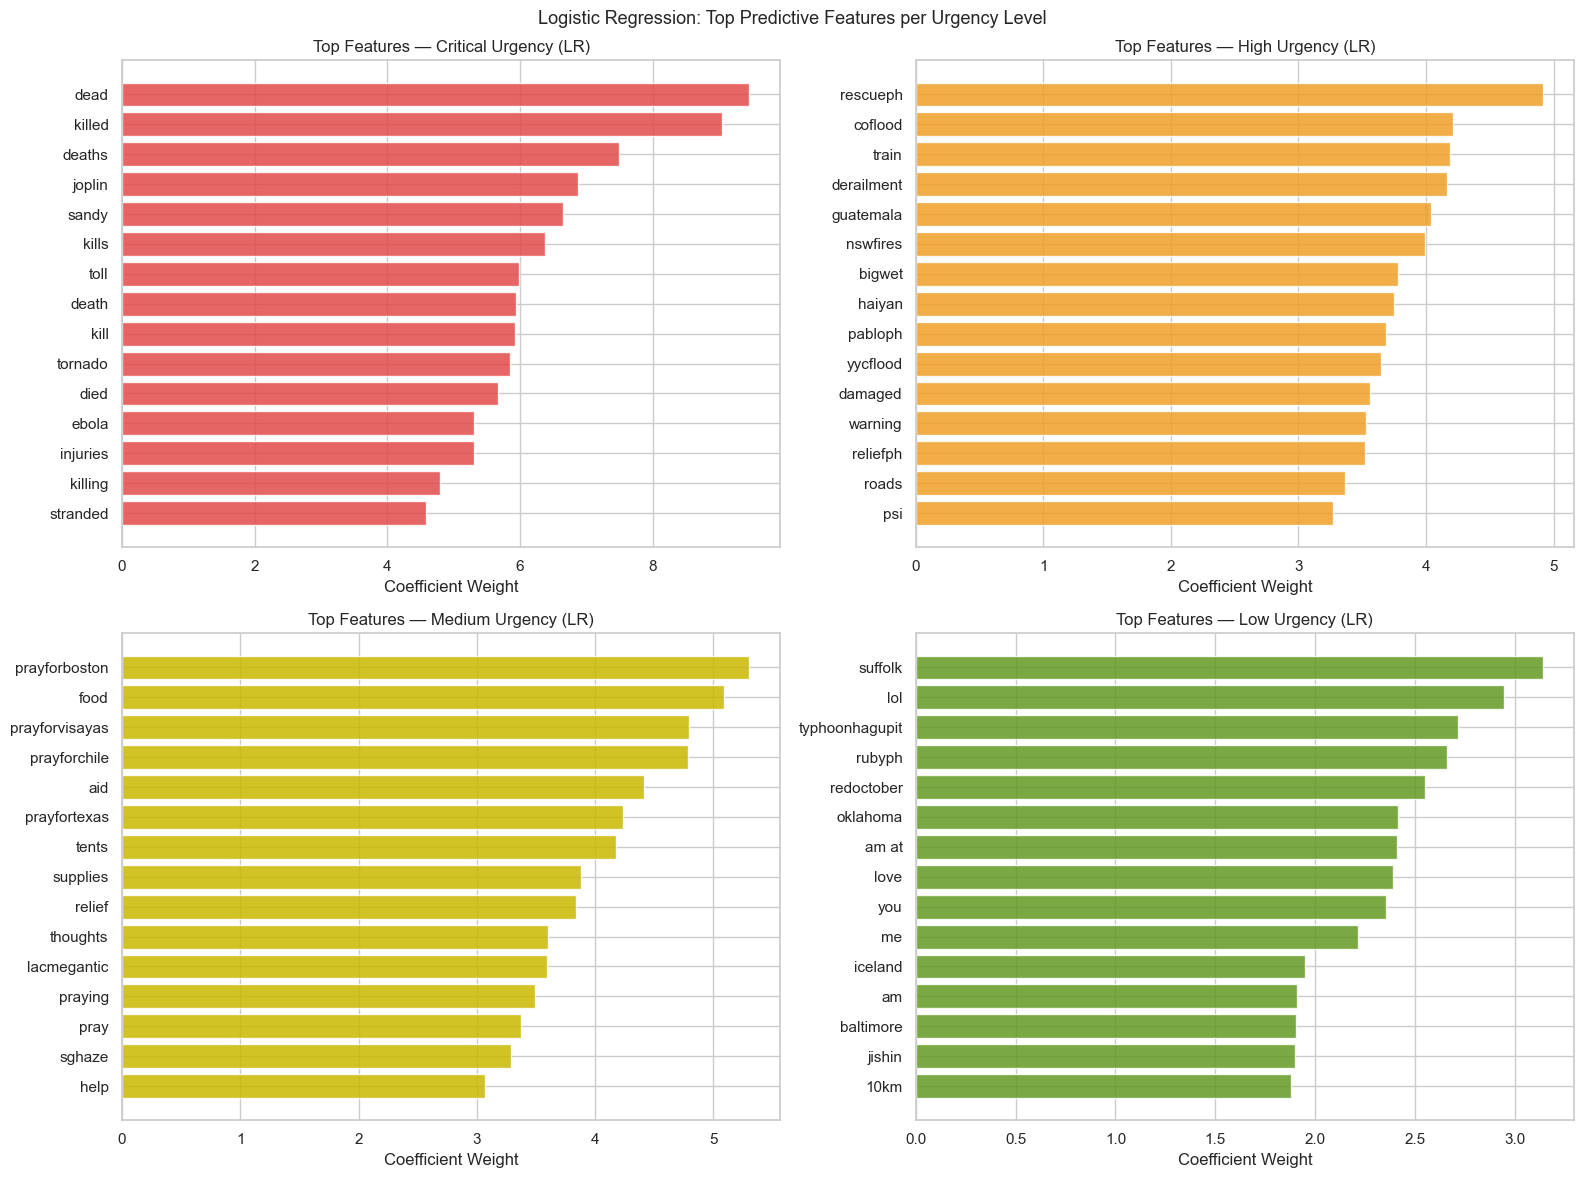

In [12]:
# Cell 13:
# ---------------------------------------------------------------------------
# Top TF-IDF features driving each model's predictions
# Shows which words most strongly indicate each urgency level
# Useful for understanding what the models learned
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

urgency_levels = ["Critical", "High", "Medium", "Low"]
urgency_colors = {
    "Critical": "#E24B4A",
    "High":     "#EF9F27",
    "Medium":   "#c9b800",
    "Low":      "#639922"
}

# Get LR coefficients per class
for i, level in enumerate(urgency_levels):
    if level not in lr_model.classes_:
        continue

    class_idx = list(lr_model.classes_).index(level)
    coefficients = lr_model.coef_[class_idx]

    # Get top 15 most important features for this class
    top_indices = np.argsort(coefficients)[-15:]
    top_features = [feature_names[j] for j in top_indices]
    top_scores = [coefficients[j] for j in top_indices]

    axes[i].barh(
        top_features,
        top_scores,
        color=urgency_colors[level],
        alpha=0.85
    )
    axes[i].set_title(f"Top Features — {level} Urgency (LR)")
    axes[i].set_xlabel("Coefficient Weight")

plt.suptitle("Logistic Regression: Top Predictive Features per Urgency Level", fontsize=13)
plt.tight_layout()
plt.savefig("../../backend/data/chart_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Cell 14:
# ---------------------------------------------------------------------------
# Test both models on the fake messages from our project report sect 3.6
# This verifies the models classify the way we expect
# ---------------------------------------------------------------------------

test_messages = [
    ("There is a strong smell of gas coming from the basement of the apartment complex on 5th Ave. People are starting to feel dizzy.", "Critical", "Environmental"),
    ("I can see smoke and orange flames on the ridge behind the high school. The wind is picking up and blowing towards the houses.", "High", "Disaster"),
    ("I have run out of my prescription heart medication and the roads are blocked by snow.", "Medium", "Medical"),
    ("I've had a scratchy throat and a mild cough for two days. No fever or trouble breathing. Are there any local clinics open today?", "Low", "Medical"),
]

print("=" * 70)
print("Testing models on our created fake messages")
print("=" * 70)

for msg, expected_urgency, expected_type in test_messages:
    cleaned = preprocess_text(msg)
    vectorized = tfidf.transform([cleaned])

    lr_pred = lr_model.predict(vectorized)[0]
    lr_prob = max(lr_model.predict_proba(vectorized)[0])

    rf_pred = rf_model.predict(vectorized)[0]
    rf_prob = max(rf_model.predict_proba(vectorized)[0])

    print(f"\nMessage: {msg[:70]}...")
    print(f"Expected:  {expected_urgency}")
    print(f"LR pred:   {lr_pred} (confidence: {lr_prob:.2f})")
    print(f"RF pred:   {rf_pred} (confidence: {rf_prob:.2f})")
    # ✓ means the model that predicted the correct urgency level matches and x means the model did not predict the correct urgency level
    print(f"LR match: {'✓' if lr_pred == expected_urgency else 'x'} | RF match: {'✓' if rf_pred == expected_urgency else 'x'}")

Testing models on our created fake messages

Message: There is a strong smell of gas coming from the basement of the apartme...
Expected:  Critical
LR pred:   High (confidence: 0.47)
RF pred:   Medium (confidence: 0.40)
LR match: x | RF match: x

Message: I can see smoke and orange flames on the ridge behind the high school....
Expected:  High
LR pred:   Low (confidence: 0.47)
RF pred:   Low (confidence: 0.64)
LR match: x | RF match: x

Message: I have run out of my prescription heart medication and the roads are b...
Expected:  Medium
LR pred:   Low (confidence: 0.57)
RF pred:   Low (confidence: 0.63)
LR match: x | RF match: x

Message: I've had a scratchy throat and a mild cough for two days. No fever or ...
Expected:  Low
LR pred:   Medium (confidence: 0.46)
RF pred:   Low (confidence: 0.64)
LR match: x | RF match: ✓


# Cell 15: Summary
## Training Summary

| Model               | Accuracy                   | Precision   | Recall       | F1 Score    |
|---------------------|----------------------------|-------------|--------------|-------------|
| Logistic Regression | see output                 | from output | from output  | from output |
| Random Forest       | see output                 | from output | from output  | from output |
| RoBERTa             | will test in Google Colab) | will test   | will test    | will test   |

- Both models trained on combined datasets
- Class weights applied to handle imbalanced urgency levels
- emergency phrases like "gas leak", "building collapse" captured
- Setting up for RoBERTa fine-tuning (looking to do on Google Colab)

In [23]:
# Cell 16
# ---------------------------------------------------------------------------
# Test RoBERTa on our fake messages from project report
# Run locally using the saved model weights
# ---------------------------------------------------------------------------

from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch

# Load saved model from local path
ROBERTA_PATH = "../../backend/models/roberta_triage"

print("Loading RoBERTa model...")
roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_PATH)
roberta_model = RobertaForSequenceClassification.from_pretrained(ROBERTA_PATH)
roberta_model.eval()

id2label = {0: "Critical", 1: "High", 2: "Medium", 3: "Low"}

test_messages = [
    ("There is a strong smell of gas coming from the basement of the apartment complex on 5th Ave. People are starting to feel dizzy.", "Critical"),
    ("I can see smoke and orange flames on the ridge behind the high school. The wind is picking up and blowing towards the houses.", "High"),
    ("I have run out of my prescription heart medication and the roads are blocked by snow.", "Medium"),
    ("I've had a scratchy throat and a mild cough for two days. No fever or trouble breathing. Are there any local clinics open today?", "Low"),
]

print("=" * 70)
print("Testing RoBERTa on fake messages from doc section 3.6")
print("=" * 70)

for msg, expected in test_messages:
    cleaned = preprocess_text(msg)
    inputs = roberta_tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        predicted_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][predicted_id].item()

    predicted_label = id2label[predicted_id]
    match = "✓" if predicted_label == expected else "✗"

    print(f"\nMessage:  {msg[:70]}...")
    print(f"Expected: {expected}")
    print(f"RoBERTa:  {predicted_label} (confidence: {confidence:.2f}) {match}")

Loading RoBERTa model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Testing RoBERTa on fake messages from doc section 3.6

Message:  There is a strong smell of gas coming from the basement of the apartme...
Expected: Critical
RoBERTa:  High (confidence: 0.58) ✗

Message:  I can see smoke and orange flames on the ridge behind the high school....
Expected: High
RoBERTa:  High (confidence: 0.87) ✓

Message:  I have run out of my prescription heart medication and the roads are b...
Expected: Medium
RoBERTa:  Low (confidence: 0.48) ✗

Message:  I've had a scratchy throat and a mild cough for two days. No fever or ...
Expected: Low
RoBERTa:  Medium (confidence: 0.99) ✗


Logistic Regression: 80.5% accuracy, F1 0.809
Random Forest:       78.0% accuracy, F1 0.782
RoBERTa:             84.8% accuracy, F1 0.851  ← best

On the 4 fake messages (informal test):
Logistic Regression: 0/4
Random Forest:       1/4
RoBERTa:             1/4

Here the 3 models struggle but RoBERTa is still the better model as:
-It scored highest on 20,085 unseen messages — that's the real measure
-It can understand context and meaning, not just keywords

The 4 fake message test is too small to draw conclusions from. Adding more data to training_data.csv to
train data RoBERTa on, would improve dramatically more than LR/RF would

When user eneters an input as well, RoBERTa model will be our primary classifier. For the datasets we DO have, Twittwe style messages will draw RoBERTa's accuracy of 84% whereas conversational descriptioins there may be higher chance of misclassification. All models showed limitations on conversational civilian language, suggesting future work should incorporate more diverse training data beyond social media posts.